<a href="https://colab.research.google.com/github/Darahas-reddy/stock-market-analysis/blob/main/visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


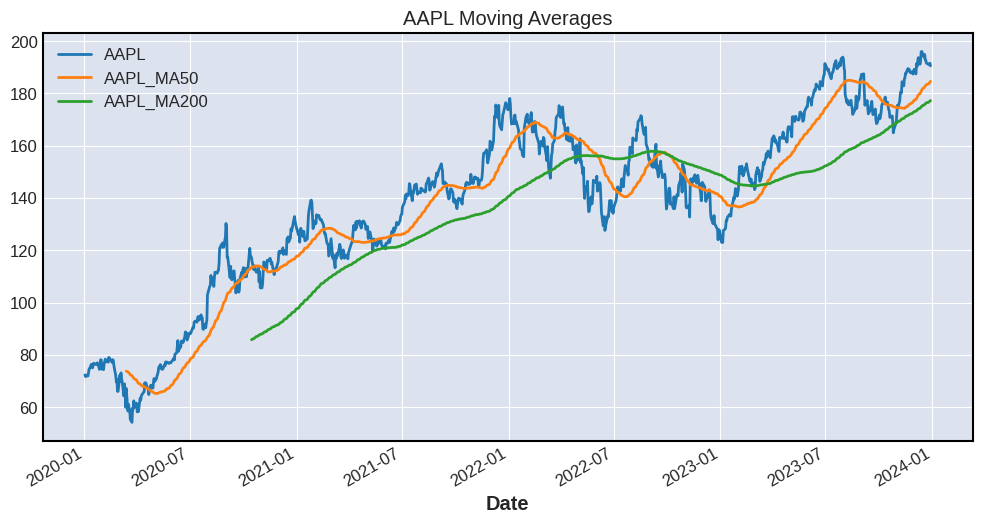

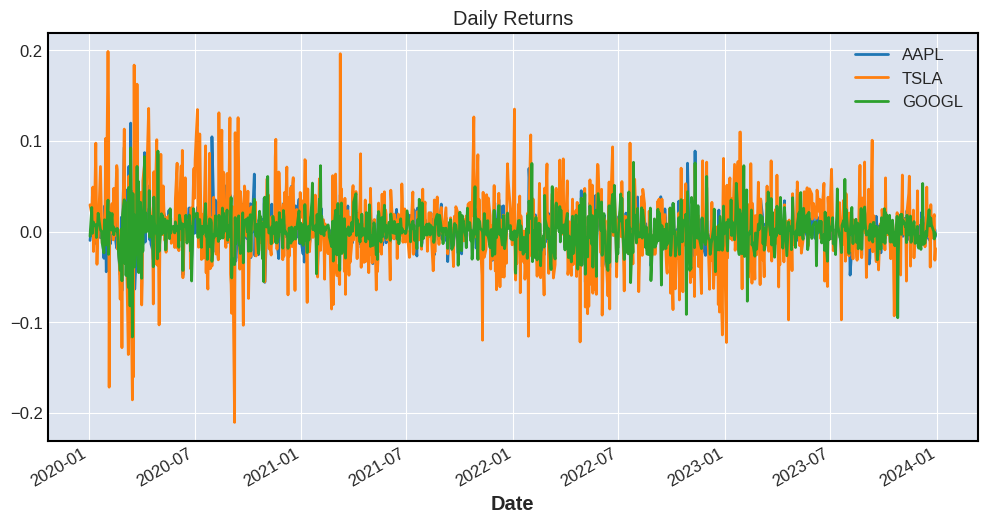

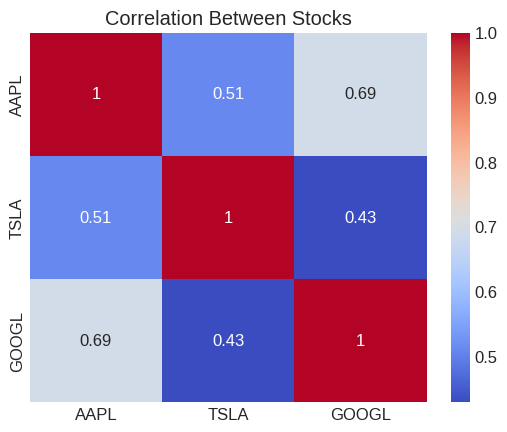

/tmp/ipykernel_5623/2383539027.py:56: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Columns before fix: MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
Columns after fix: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


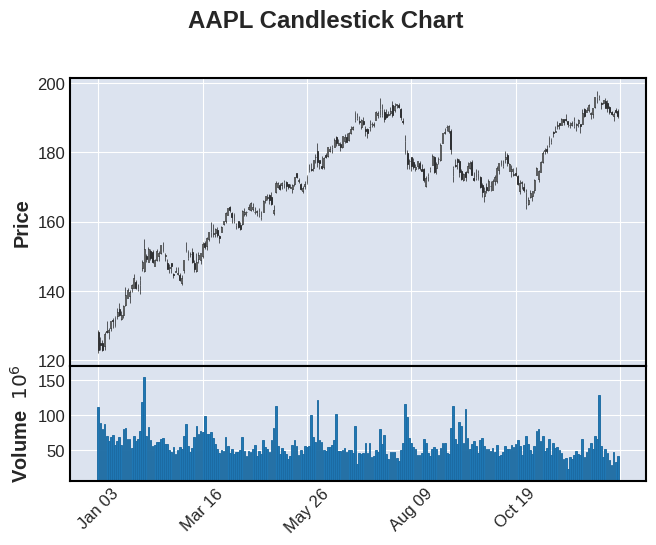

In [8]:
!pip install yfinance mplfinance seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
import yfinance as yf

%matplotlib inline

data = pd.read_csv("/content/drive/MyDrive/stock-market-analysis/stocks_cleaned.csv",
                   index_col=0, parse_dates=True)

stocks = ['AAPL', 'TSLA', 'GOOGL']

for stock in stocks:
    data[f'{stock}_MA50'] = data[stock].rolling(window=50).mean()
    data[f'{stock}_MA200'] = data[stock].rolling(window=200).mean()

data[['AAPL','AAPL_MA50','AAPL_MA200']].plot(figsize=(12,6))
plt.title("AAPL Moving Averages")
plt.show()


returns = data[stocks].pct_change()

returns.plot(figsize=(12,6))
plt.title("Daily Returns")
plt.show()


corr = returns.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Stocks")
plt.show()


raw_data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

print("Columns before fix:", raw_data.columns)

import pandas as pd
if isinstance(raw_data.columns, pd.MultiIndex):
    raw_data.columns = raw_data.columns.get_level_values(0)

print("Columns after fix:", raw_data.columns)

raw_data = raw_data.dropna()
mpf.plot(raw_data, type='candle', volume=True, title='AAPL Candlestick Chart')